# Bài 11: Cơ bản về Shapely

Chào mừng bạn đến với bài học đầu tiên về phân tích dữ liệu địa không gian với Python! Trong bài học này, chúng ta sẽ khám phá Shapely - một thư viện nền tảng để thao tác và phân tích các đối tượng hình học phẳng trong Python.

Shapely dựa trên thư viện GEOS được sử dụng rộng rãi (công cụ hình học của PostGIS) và cung cấp giao diện Python đơn giản, trực quan để làm việc với các hình dạng hình học 2D.

## 11.1. Mục tiêu học tập
Sau khi hoàn thành bài học này, bạn sẽ có thể:
- Tạo và thao tác các đối tượng hình học cơ bản (Point, LineString, Polygon)
- Hiểu các thuộc tính và phương thức của đối tượng hình học
- Thực hiện các phép toán không gian (buffer, intersection, union, difference)
- Kiểm tra mối quan hệ không gian (contains, intersects, touches)
- Áp dụng các phép biến đổi hình học (rotate, scale, translate)
- Làm việc với các đối tượng đa hình học phức tạp
- Tối ưu hóa hiệu suất cho dữ liệu không gian lớn

In [ ]:
# Nếu chưa cài đặt Shapely, bạn có thể cài đặt bằng pip: pip install shapely hoặc xem lại Bài 1 về cách cài đặt thư viện.
from shapely.geometry import Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon
from shapely.geometry import GeometryCollection
from shapely.ops import unary_union, transform, nearest_points, split
from shapely import affinity
from shapely.validation import make_valid
# Thư viện cần thiết khác
import numpy as np
import matplotlib.pyplot as plt

## 11.2. Các đối tượng hình học cơ bản

Shapely cung cấp các lớp để biểu diễn các đối tượng hình học. Hiểu những điều này là cần thiết:

- **Point (Điểm)**: Hình học 0 chiều (tọa độ x, y)
- **LineString (Đường)**: Hình học 1 chiều (chuỗi các điểm liên kết)
- **Polygon (Đa giác)**: Hình học 2 chiều (vùng khép kín có thể có lỗ)
- **Multi-geometries (Đa hình học)**: Tập hợp các hình học cùng loại

### 11.2.1. Tạo điểm và kiểm tra thuộc tính

Chúng ta có thể tạo ra 1 điểm (`Point` object) từ tọa độ (x,y). 

In [135]:
# Tạo điểm - các cách khác nhau
point1 = Point(0, 0)                    # Điểm cơ bản
point2 = Point([1, 1])                  # Từ list/tuple
point3 = Point(np.array([2, 2]))        # Từ mảng numpy
# Chúng ta có thể kiểm tra các thuộc tính và phương thức của điểm như sau:
print(f"Tọa độ điểm 1: ({point1.x}, {point1.y})")
print(f"Điểm 1 WKT: {point1.wkt}")
# Thuộc tính điểm
print(f"Giới hạn điểm (minx, miny, maxx, maxy): {point1.bounds}")
print(f"Điểm có trống: {point1.is_empty}")
print(f"Điểm hợp lệ: {point1.is_valid}")
print(f"Khoảng cách từ điểm 1 đến điểm 2: {point1.distance(point2)}")

Tọa độ điểm 1: (0.0, 0.0)
Điểm 1 WKT: POINT (0 0)
Giới hạn điểm (minx, miny, maxx, maxy): (0.0, 0.0, 0.0, 0.0)
Điểm có trống: False
Điểm hợp lệ: True
Khoảng cách từ điểm 1 đến điểm 2: 1.4142135623730951


### 11.2.2. Tạo đường và kiểm tra thuộc tính

Đường (Line) được tạo ra từ một danh sách các điểm (các cặp tọa độ (x, y)) như sau.

In [136]:
# Tạo đường
line1 = LineString([(0, 0), (1, 1), (2, 0), (3, 1)])
line2 = LineString([point1, point2, point3])
# Kiểm tra các thuộc tính của đường 
print(f"Tọa độ đường 1: {list(line1.coords)}")
print(f"Độ dài đường 1: {line1.length:.3f}")
print(f"Đường 1 khép kín: {line1.is_closed}")
print(f"Đường 1 đơn giản (không tự cắt): {line1.is_simple}")

# Truy cập các phần của đường
print(f"Điểm bắt đầu: {Point(line1.coords[0])}")
print(f"Điểm kết thúc: {Point(line1.coords[-1])}")

Tọa độ đường 1: [(0.0, 0.0), (1.0, 1.0), (2.0, 0.0), (3.0, 1.0)]
Độ dài đường 1: 4.243
Đường 1 khép kín: False
Đường 1 đơn giản (không tự cắt): True
Điểm bắt đầu: POINT (0 0)
Điểm kết thúc: POINT (3 1)


### 11.2.3. Tạo Polygon và kiểm tra thuộc tính

Polygon được tạo ra từ một danh sách các điểm (các cặp tọa độ (x, y)), trong đó điểm đầu và điểm cuối thường trùng nhau để tạo thành một vùng khép kín.

- **Đa giác đơn giản**

Đa giác là một hình dạng phẳng được xác định bởi một chuỗi các điểm (đỉnh) kết nối với nhau để tạo thành một vùng kín.

In [ ]:
# Đa giác đơn giản (tam giác)
triangle = Polygon([(0, 0), (1, 0), (0.5, 1), (0, 0)])
print(f"Diện tích tam giác: {triangle.area:.3f}")

Diện tích tam giác: 0.500


- **Đa giác vuông**

Diện tích hình vuông: 4.000


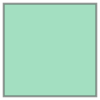

In [ ]:
# Đa giác vuông
square_coords = [(0, 0), (2, 0), (2, 2), (0, 2), (0, 0)]
square = Polygon(square_coords)
print(f"Diện tích hình vuông: {square.area:.3f}")
square

- **Đa giác có lỗ (interiors)**

Đa giác có lỗ là một hình dạng phức tạp hơn, nơi có một vùng bên trong bị loại bỏ (lỗ) khỏi vùng bên ngoài. Ví dụ, hình donut là một đa giác có lỗ, với phần lỗ ở giữa được loại bỏ khỏi phần bên ngoài. Điều này cho phép chúng ta mô hình hóa các đối tượng như hồ, đảo, hoặc các khu vực có ranh giới phức tạp trong GIS.

Diện tích hình donut: 12.000
Donut có 1 lỗ bên trong
Đường biên ngoài hình donut: [(0.0, 0.0), (4.0, 0.0), (4.0, 4.0), (0.0, 4.0), (0.0, 0.0)]
Đường biên lỗ bên trong: [[(1.0, 1.0), (3.0, 1.0), (3.0, 3.0), (1.0, 3.0), (1.0, 1.0)]]


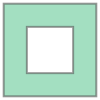

In [ ]:
# Đa giác có lỗ (hình donut)
exterior = [(0, 0), (4, 0), (4, 4), (0, 4), (0, 0)]
interior = [(1, 1), (3, 1), (3, 3), (1, 3), (1, 1)]  # lỗ
donut = Polygon(exterior, [interior])
print(f"Diện tích hình donut: {donut.area:.3f}")
print(f"Donut có {len(donut.interiors)} lỗ bên trong")
print(f"Đường biên ngoài hình donut: {list(donut.exterior.coords)}")
print(f"Đường biên lỗ bên trong: {[list(interior.coords) for interior in donut.interiors]}")
donut

### 11.2.4. Trực quan hóa điểm, đường và đa giác

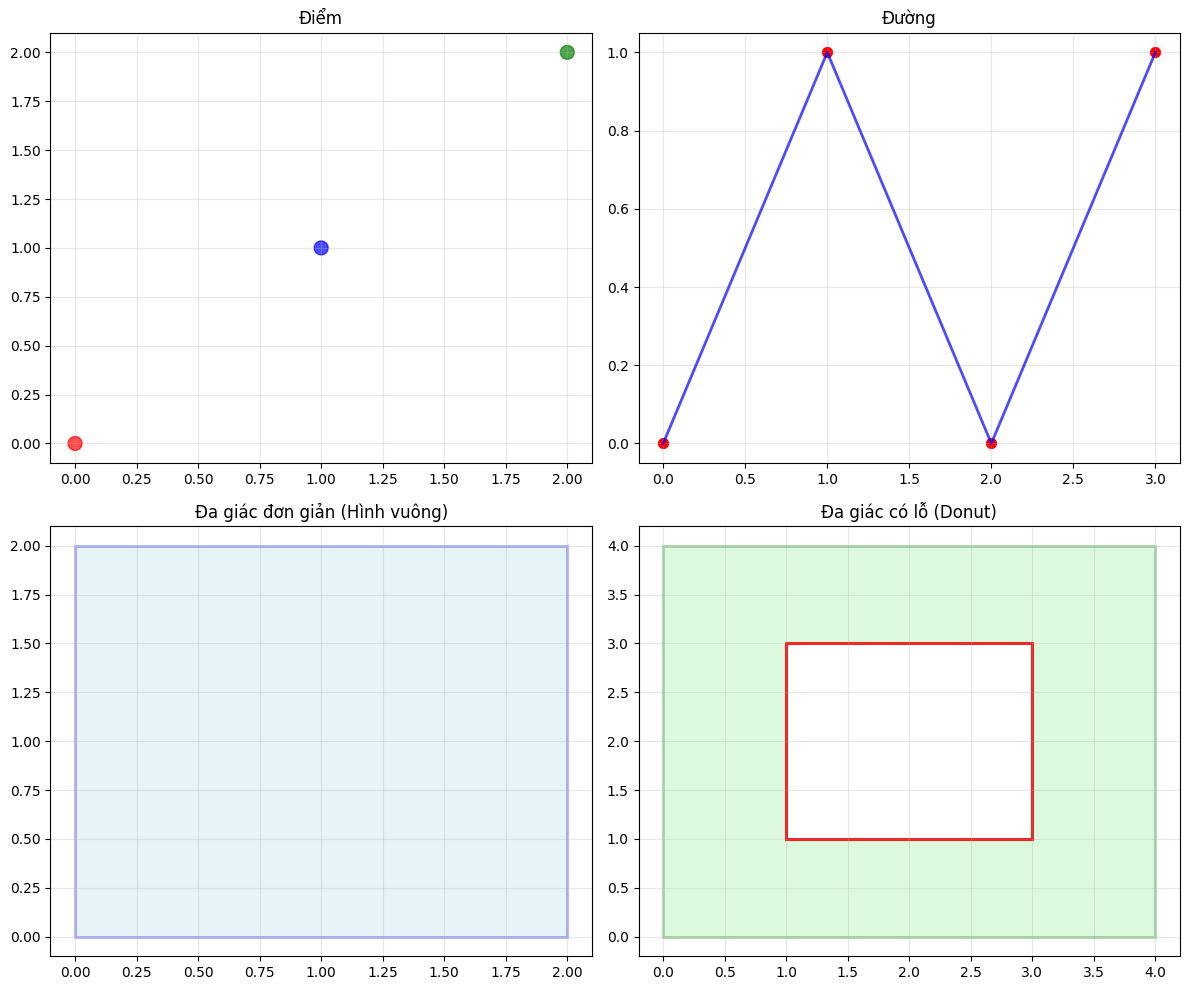

In [140]:
# Trực quan hóa các hình học cơ bản
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Biểu đồ 1: Điểm
axes[0, 0].scatter([point1.x, point2.x, point3.x], 
                   [point1.y, point2.y, point3.y], 
                   c=['red', 'blue', 'green'], s=100, alpha=0.7)
axes[0, 0].set_title('Điểm')
axes[0, 0].grid(True, alpha=0.3)

# Biểu đồ 2: Đường
x, y = line1.xy
axes[0, 1].plot(x, y, 'b-', linewidth=2, alpha=0.7)
axes[0, 1].scatter(x, y, c='red', s=50)
axes[0, 1].set_title('Đường')
axes[0, 1].grid(True, alpha=0.3)

# Biểu đồ 3: Đa giác đơn giản
x, y = square.exterior.xy
axes[1, 0].fill(x, y, alpha=0.3, fc='lightblue', ec='blue', linewidth=2)
axes[1, 0].set_title('Đa giác đơn giản (Hình vuông)')
axes[1, 0].grid(True, alpha=0.3)

# Biểu đồ 4: Đa giác có lỗ
x_ext, y_ext = donut.exterior.xy
x_int, y_int = donut.interiors[0].xy
axes[1, 1].fill(x_ext, y_ext, alpha=0.3, fc='lightgreen', ec='green', linewidth=2)
axes[1, 1].fill(x_int, y_int, alpha=1, fc='white', ec='red', linewidth=2)
axes[1, 1].set_title('Đa giác có lỗ (Donut)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11.3. Mối quan hệ không gian

Kiểm tra mối quan hệ không gian giữa các đối tượng hình học.

In [141]:
# Tạo hình học thử nghiệm cho mối quan hệ không gian
circle = Point(0, 0).buffer(1)  # Hình tròn bán kính 1
square_small = Polygon([(-0.5, -0.5), (0.5, -0.5), (0.5, 0.5), (-0.5, 0.5)])
line_through = LineString([(-2, 0), (2, 0)])  # Đường qua tâm
line_outside = LineString([(-2, 2), (2, 2)])   # Đường bên ngoài
point_inside = Point(0, 0)
point_outside = Point(2, 2)
point_on_boundary = Point(1, 0)

### 11.3.1. Mối quan hệ chứa

Quan hệ chứa (contains) biểu thị rằng một đối tượng hình học nằm hoàn toàn trong phạm vi của một đối tượng hình học khác, không có phần nào vượt ra ngoài ranh giới của đối tượng chứa.

In [ ]:
# Mối quan hệ chứa
print(f"Hình tròn chứa hình vuông: {circle.contains(square_small)}") # True vì hình tròn chứa hoàn toàn hình vuông nhỏ
print(f"Hình tròn chứa điểm bên trong: {circle.contains(point_inside)}")
print(f"Hình tròn chứa điểm bên ngoài: {circle.contains(point_outside)}")
print(f"Hình vuông nằm trong hình tròn: {square_small.within(circle)}")

Hình tròn chứa hình vuông: True
Hình tròn chứa điểm bên trong: True
Hình tròn chứa điểm bên ngoài: False
Hình vuông nằm trong hình tròn: True


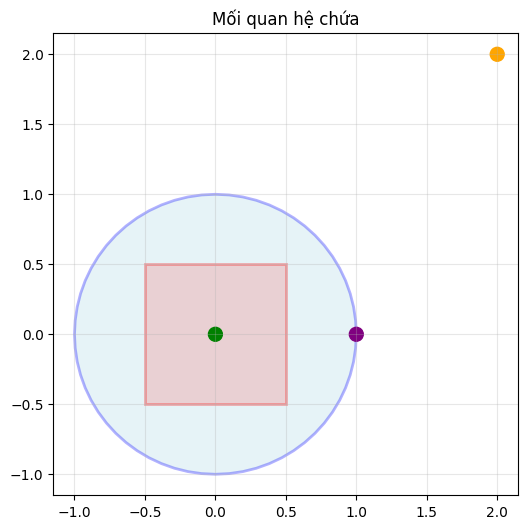

In [143]:
fig, ax = plt.subplots(figsize=(6, 6))
x, y = circle.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightblue', ec='blue', linewidth=2, label='Circle')
x, y = square_small.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightcoral', ec='red', linewidth=2, label='Square Small')
ax.scatter([point_inside.x, point_outside.x, point_on_boundary.x],
           [point_inside.y, point_outside.y, point_on_boundary.y],
           c=['green', 'orange', 'purple'], s=100, label='Points')
ax.set_title('Mối quan hệ chứa')
ax.grid(True, alpha=0.3)
plt.show()

### 11.3.2. Mối quan hệ giao nhau

Mối quan hệ giao nhau cho phép chúng ta xác định xem hai hình học có phần nào đó chồng lên nhau hay không.

In [ ]:
# Mối quan hệ giao nhau
print(f"Hình tròn giao với đường qua tâm: {circle.intersects(line_through)}")
print(f"Hình tròn giao với đường bên ngoài: {circle.intersects(line_outside)}")
print(f"Hình tròn giao với hình vuông: {circle.intersects(square_small)}")

Hình tròn giao với đường qua tâm: True
Hình tròn giao với đường bên ngoài: False
Hình tròn giao với hình vuông: True


Text(0.5, 1.0, 'Mối quan hệ giao nhau')

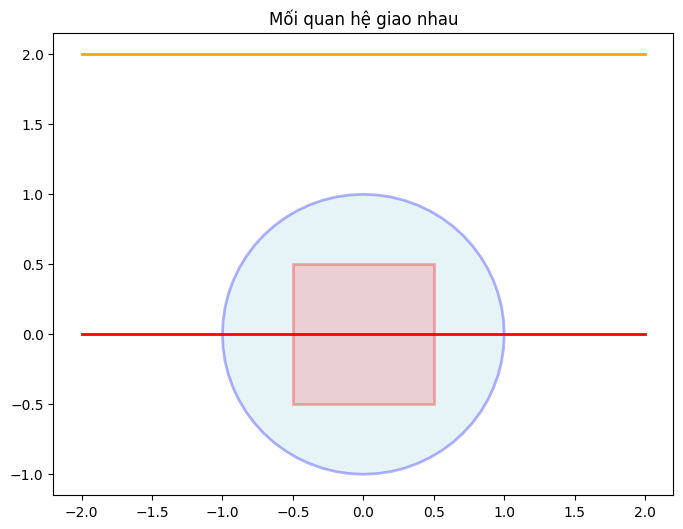

In [145]:
fig, ax = plt.subplots(figsize=(8,6))
x, y = circle.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightblue', ec='blue', linewidth=2, label='Circle')
x, y = line_through.xy 
ax.plot(x, y, 'r-', linewidth=2, label='Line Through')
x, y = line_outside.xy
ax.plot(x, y, 'orange', linewidth=2, label='Line Outside')
x, y = square_small.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightcoral', ec='red', linewidth=2, label='Square Small')
ax.set_title('Mối quan hệ giao nhau')

### 11.3.3. Mối quan hệ biên

Quan hệ biên (touches) xác định xem hai hình học có chạm nhau tại một điểm hoặc một đoạn mà không có phần nào nằm bên trong phần còn lại hay không.

In [ ]:
# Mối quan hệ biên
print(f"Điểm trên biên chạm hình tròn: {point_on_boundary.touches(circle)}")
print(f"Điểm bên trong chạm hình tròn: {point_inside.touches(circle)}")
print(f"Đường qua tâm cắt hình tròn: {line_through.crosses(circle)}")

Điểm trên biên chạm hình tròn: True
Điểm bên trong chạm hình tròn: False
Đường qua tâm cắt hình tròn: True


### 11.3.4. Mối quan hệ khoảng cách

Quan hệ khoảng cách giúp chúng ta hiểu được mức độ gần gũi hoặc xa lạ giữa các đối tượng không gian. 

In [ ]:
# Mối quan hệ khoảng cách
print(f"Khoảng cách từ điểm ngoài đến hình tròn: {point_outside.distance(circle):.3f}")
print(f"Khoảng cách từ điểm trong đến hình tròn: {point_inside.distance(circle):.3f}")
print(f"Khoảng cách giữa hình tròn và hình vuông: {circle.distance(square_small):.3f}")

Khoảng cách từ điểm ngoài đến hình tròn: 1.828
Khoảng cách từ điểm trong đến hình tròn: 0.000
Khoảng cách giữa hình tròn và hình vuông: 0.000


### 11.3.5. Mối quan hệ topo

Mối quan hệ topo là một mô hình để mô tả các mối quan hệ không gian giữa các đối tượng hình học. Bằng cách sử dụng các phương thức như equals, disjoint, và covers, chúng ta có thể xác định chính xác cách mà các đối tượng này tương tác với nhau trong không gian.

In [ ]:
# Mối quan hệ topo (mô hình DE-9IM)
print(f"Hình tròn bằng chính nó: {circle.equals(circle)}")
print(f"Các hình học tách rời (không chạm): {circle.disjoint(point_outside)}")
print(f"Hình vuông bao phủ điểm bên trong: {square_small.covers(Point(0, 0))}")

Hình tròn bằng chính nó: True
Các hình học tách rời (không chạm): True
Hình vuông bao phủ điểm bên trong: True


### 11.3.6. Mối quan hệ chồng lấp

Mối quan hệ chồng lấp (overlaps) cho phép chúng ta xác định xem hai đối tượng hình học có phần nào đó giao nhau nhưng không hoàn toàn chứa nhau hay không.

In [ ]:
# Kiểm tra mối quan hệ chồng lấp
overlap_square = Polygon([(0.5, -0.5), (1.5, -0.5), (1.5, 0.5), (0.5, 0.5)])
print(f"Hình tròn chồng lấp với hình vuông dịch chuyển: {circle.overlaps(overlap_square)}")

Hình tròn chồng lấp với hình vuông dịch chuyển: True


## 11.4.Tạo buffer cho điểm, đường và polygon

Buffer là thao tác tạo vùng đệm xung quanh các đối tượng không gian như điểm (point), đường (line) và vùng (polygon) theo một khoảng cách xác định. Đây là một phép phân tích không gian quan trọng, thường được sử dụng để xác định vùng ảnh hưởng, vùng lân cận hoặc phục vụ các bài toán phân tích khoảng cách trong GIS.

### 11.4.1. Tạo buffer cho điểm

In [150]:
# 1. PHÉP TOÁN ĐỆM
point_buffer = Point(0, 0).buffer(1)

### 11.4.2. Tạo buffer cho đường

In [151]:
line = LineString([(0.5, 0.5), (2.5, 2.5)])        # Đường chéo
line_buffer = line.buffer(0.2)

### 11.4.3. Tạo buffer cho polygon

In [152]:
# Tạo hình học cơ sở để thao tác
poly = Polygon([(0, 0), (2, 0), (2, 2), (0, 2)])  # Hình vuông
polygon_buffer = poly.buffer(0.5)

## 11.5. Phép biến đổi hình học

Áp dụng các phép biến đổi như xoay, co giãn và tịnh tiến cho hình học.

In [153]:
# Tạo hình học cơ sở để biến đổi
original_polygon = Polygon([(0, 0), (2, 0), (2, 1), (0, 1)])  # Hình chữ nhật

### 11.5.1. Phép tịnh tiến

Phép tịnh tiến là phép biến hình dịch chuyển toàn bộ đối tượng đi một khoảng xác định theo hướng xác định, trong đó hình dạng, kích thước và hướng của đối tượng được giữ nguyên.

In [154]:
# TỊNH TIẾN (Translation)
translated = affinity.translate(original_polygon, xoff=3, yoff=2)
print(f"Tịnh tiến theo x=3, y=2")
print(f"Tâm hình gốc: ({original_polygon.centroid.x:.1f}, {original_polygon.centroid.y:.1f})")
print(f"Tâm sau tịnh tiến: ({translated.centroid.x:.1f}, {translated.centroid.y:.1f})")

Tịnh tiến theo x=3, y=2
Tâm hình gốc: (1.0, 0.5)
Tâm sau tịnh tiến: (4.0, 2.5)


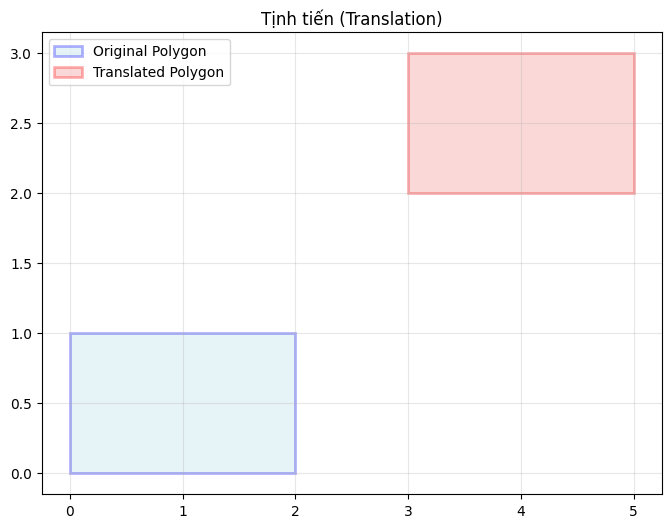

In [155]:
# Hiển thị vị trí gốc và phép tịnh tiến
fig, ax = plt.subplots(figsize=(8, 6))
x, y = original_polygon.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightblue', ec='blue', linewidth=2, label='Original Polygon')
x, y = translated.exterior.xy   
ax.fill(x, y, alpha=0.3, fc='lightcoral', ec='red', linewidth=2, label='Translated Polygon')
ax.set_title('Tịnh tiến (Translation)')
ax.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 11.5.2. Phép xoay

Phép xoay là phép biến hình trong đó một đối tượng được quay quanh một điểm cố định (gọi là tâm xoay) theo một góc xác định, trong khi giữ nguyên hình dạng và kích thước của đối tượng.

In [156]:
# XOAY (Rotation)
rotated_45 = affinity.rotate(original_polygon, 45, origin='center')  # Xoay 45 độ quanh tâm
rotated_90 = affinity.rotate(original_polygon, 90, origin=(0, 0))   # Xoay 90 độ quanh gốc

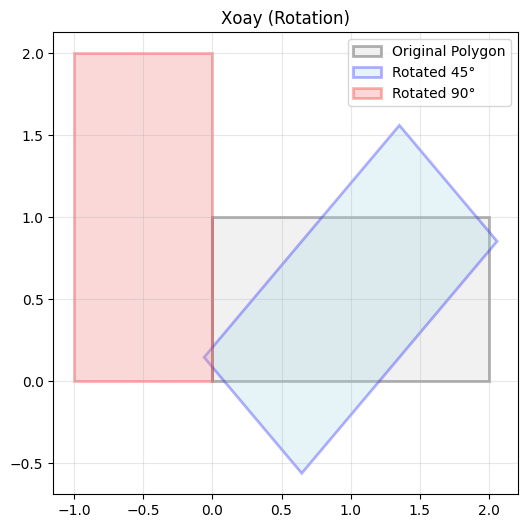

In [157]:
fig, ax = plt.subplots(figsize=(6, 6))
x, y = original_polygon.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightgray', ec='black', linewidth=2, label='Original Polygon')
# hiển thị rotate 45 và 90 độ
x, y = rotated_45.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightblue', ec='blue', linewidth=2, label='Rotated 45°')
x, y = rotated_90.exterior.xy   
ax.fill(x, y, alpha=0.3, fc='lightcoral', ec='red', linewidth=2, label='Rotated 90°')
ax.set_title('Xoay (Rotation)') 
ax.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 11.5.3. Phép scaling 

Phép scaling (phép co giãn) là phép biến hình làm thay đổi kích thước của đối tượng theo một hoặc nhiều chiều, bằng cách nhân tọa độ với một hệ số tỉ lệ, trong khi giữ nguyên hình dạng và hướng (nếu tỉ lệ dương).

In [158]:
# CO GIÃN (Scaling)
scaled_up = affinity.scale(original_polygon, xfact=2, yfact=1.5)  # Phóng to x2, y1.5
scaled_down = affinity.scale(original_polygon, xfact=0.5, yfact=0.5) # Thu nhỏ 0.5
print(f"Diện tích gốc: {original_polygon.area}")
print(f"Diện tích phóng to (2x, 1.5y): {scaled_up.area}")
print(f"Diện tích thu nhỏ (0.5x, 0.5y): {scaled_down.area}")

Diện tích gốc: 2.0
Diện tích phóng to (2x, 1.5y): 6.0
Diện tích thu nhỏ (0.5x, 0.5y): 0.5


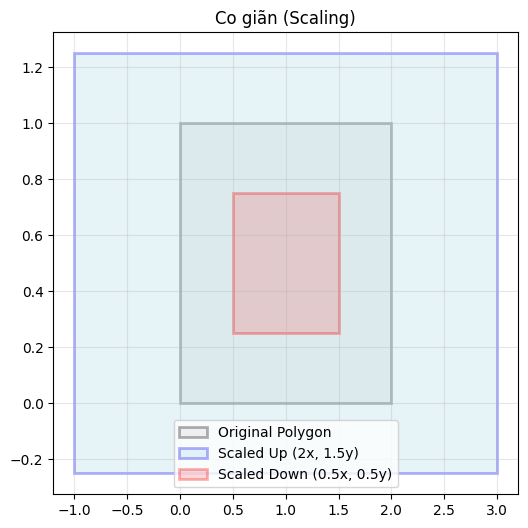

In [159]:
fig, ax = plt.subplots(figsize=(6, 6))
x, y = original_polygon.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightgray', ec='black', linewidth=2, label='Original Polygon')

# hiển thị scaling lên và xuống
x, y = scaled_up.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightblue', ec='blue', linewidth=2, label='Scaled Up (2x, 1.5y)')
x, y = scaled_down.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightcoral', ec='red', linewidth=2, label='Scaled Down (0.5x, 0.5y)')
ax.set_title('Co giãn (Scaling)')
ax.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 11.5.4. Phép biến dạng (Skew/shear)

In [160]:
# BIẾN DẠNG (Skew/Shear)
skewed = affinity.skew(original_polygon, xs=15, ys=0)  # Nghiêng 15 độ theo trục x
print(f"Biến dạng nghiêng 15° theo trục x")
print(f"Diện tích sau biến dạng: {skewed.area:.3f}")

Biến dạng nghiêng 15° theo trục x
Diện tích sau biến dạng: 2.000


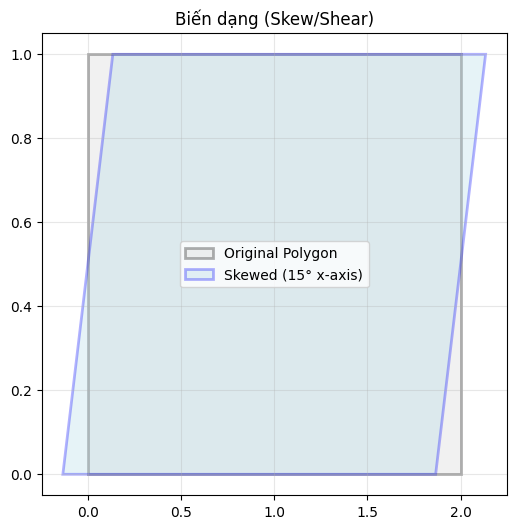

In [161]:
fig, ax = plt.subplots(figsize=(6, 6))
x, y = original_polygon.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightgray', ec='black', linewidth=2, label='Original Polygon')
x, y = skewed.exterior.xy
ax.fill(x, y, alpha=0.3, fc='lightblue', ec='blue', linewidth=2, label='Skewed (15° x-axis)')
ax.set_title('Biến dạng (Skew/Shear)')
ax.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 11.6. Đa hình học và tập hợp

Làm việc với các tập hợp đối tượng hình học.

### 11.6.1. Nhiều điểm (MULTIPOINT)

MultiPoint là kiểu hình học dùng để biểu diễn một tập hợp gồm nhiều điểm (Point) riêng biệt trong cùng một đối tượng không gian. Kiểu dữ liệu này thường được sử dụng để lưu trữ hoặc xử lý các đối tượng có nhiều vị trí, chẳng hạn như các điểm quan trắc, trạm đo hoặc vị trí sự kiện trên bản đồ.

In [162]:
# Tạo tập hợp nhiều điểm
points_list = [Point(0, 0), Point(1, 1), Point(2, 0), Point(1, -1)]
multipoint = MultiPoint(points_list)
# cach khachhác nhau để tạo MultiPoint
# multipoint = MultiPoint([(0, 0), (1, 1), (2, 0), (1, -1)])
print(f"Số điểm trong MultiPoint: {len(multipoint.geoms)}")
print(f"Giới hạn MultiPoint: {multipoint.bounds}")
print(f"Diện tích bao lồi: {multipoint.convex_hull.area:.3f}")

# Truy cập từng điểm
for i, point in enumerate(multipoint.geoms):
    print(f"Điểm {i+1}: ({point.x}, {point.y})")

Số điểm trong MultiPoint: 4
Giới hạn MultiPoint: (0.0, -1.0, 2.0, 1.0)
Diện tích bao lồi: 2.000
Điểm 1: (0.0, 0.0)
Điểm 2: (1.0, 1.0)
Điểm 3: (2.0, 0.0)
Điểm 4: (1.0, -1.0)


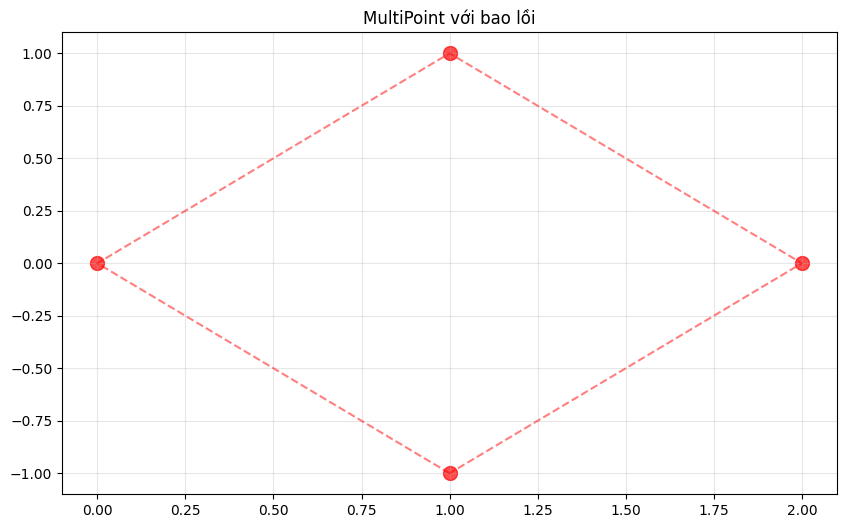

In [163]:
# Trực quan hóa các đa hình học
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# 1. MultiPoint
x_coords = [p.x for p in multipoint.geoms]
y_coords = [p.y for p in multipoint.geoms]
ax.scatter(x_coords, y_coords, c='red', s=100, alpha=0.7)
# Vẽ bao lồi
hull_x, hull_y = multipoint.convex_hull.exterior.xy
ax.plot(hull_x, hull_y, 'r--', alpha=0.5)
ax.set_title('MultiPoint với bao lồi')
ax.grid(True, alpha=0.3)

### 11.6.2. Nhiều đường (MultiLineString)

MultiLineString là kiểu hình học dùng để biểu diễn một tập hợp gồm nhiều đường (LineString) riêng biệt trong cùng một đối tượng không gian. Kiểu dữ liệu này thường được sử dụng để lưu trữ các đối tượng có nhiều đoạn đường hoặc tuyến không liên tục, chẳng hạn như mạng lưới sông ngòi, hệ thống giao thông hoặc các tuyến hạ tầng kỹ thuật trên bản đồ.

In [164]:
# Tạo nhiều đường
line1 = LineString([(0, 0), (1, 1), (2, 1)])
line2 = LineString([(0, 2), (1, 3), (2, 2)])
line3 = LineString([(3, 0), (4, 1), (5, 0)])
multiline = MultiLineString([line1, line2, line3])

print(f"Số đường trong MultiLineString: {len(multiline.geoms)}")
total_length = sum(line.length for line in multiline.geoms)
print(f"Tổng độ dài các đường: {total_length:.3f}")
print(f"Độ dài từ thuộc tính: {multiline.length:.3f}")

Số đường trong MultiLineString: 3
Tổng độ dài các đường: 8.071
Độ dài từ thuộc tính: 8.071


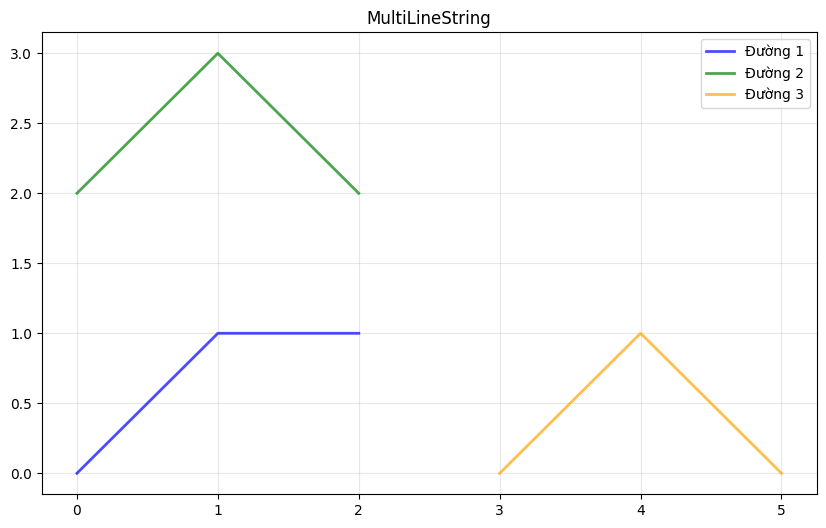

In [165]:
# Trực quan hóa các đa hình học
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
colors = ['blue', 'green', 'orange']
for i, line in enumerate(multiline.geoms):
    x, y = line.xy
    ax.plot(x, y, color=colors[i], linewidth=2, alpha=0.7, label=f'Đường {i+1}')
ax.set_title('MultiLineString')
ax.legend()
ax.grid(True, alpha=0.3)

### 11.6.3. Nhiều đa giác (MULTIPOLYGON)

MultiPolygon là kiểu hình học dùng để biểu diễn một tập hợp gồm nhiều vùng (Polygon) riêng biệt trong cùng một đối tượng không gian. Kiểu dữ liệu này thường được sử dụng để lưu trữ các đối tượng có nhiều khu vực tách rời nhau, chẳng hạn như quần đảo, các khu bảo tồn phân tán hoặc các đơn vị hành chính gồm nhiều phần lãnh thổ không liền kề.

In [166]:
# Tạo nhiều đa giác
poly1 = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])
poly2 = Polygon([(2, 0), (3, 0), (3, 1), (2, 1)])
poly3 = Polygon([(0, 2), (2, 2), (2, 4), (0, 4)])
multipolygon = MultiPolygon([poly1, poly2, poly3])

print(f"Số đa giác trong MultiPolygon: {len(multipolygon.geoms)}")
total_area = sum(poly.area for poly in multipolygon.geoms)
print(f"Tổng diện tích các đa giác: {total_area}")
print(f"Diện tích từ thuộc tính: {multipolygon.area}")

Số đa giác trong MultiPolygon: 3
Tổng diện tích các đa giác: 6.0
Diện tích từ thuộc tính: 6.0


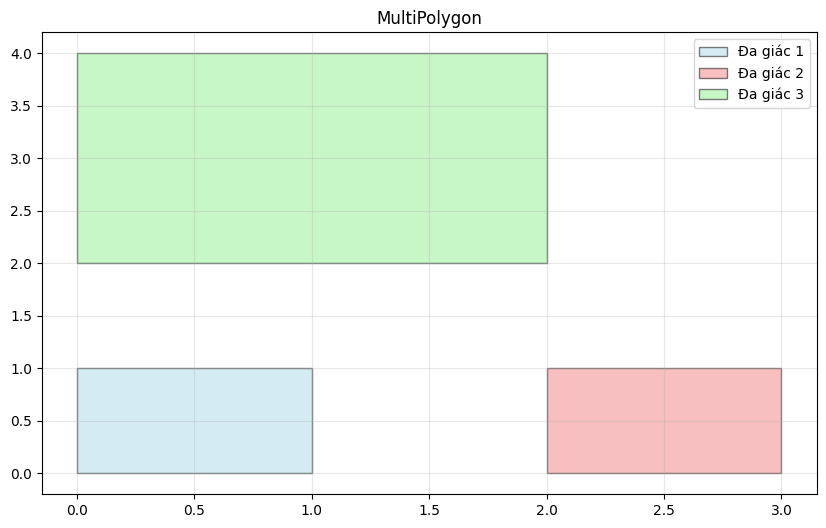

In [167]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
colors = ['lightblue', 'lightcoral', 'lightgreen']
for i, poly in enumerate(multipolygon.geoms):
    x, y = poly.exterior.xy
    ax.fill(x, y, alpha=0.5, fc=colors[i], ec='black', linewidth=1, label=f'Đa giác {i+1}')
ax.set_title('MultiPolygon')
ax.legend()
ax.grid(True, alpha=0.3)

### 11.6.4. Tập hợp geometry hỗn hợp (GEOMETRYCOLLECTION)

GeometryCollection là kiểu hình học dùng để lưu trữ nhiều đối tượng không gian thuộc các loại khác nhau trong cùng một cấu trúc dữ liệu. Một GeometryCollection có thể chứa đồng thời điểm (Point), đường (LineString), vùng (Polygon) hoặc các kiểu hình học phức tạp khác, giúp biểu diễn các đối tượng không gian đa dạng trong một thực thể duy nhất.

In [168]:
# Tạo tập hợp các loại hình học khác nhau
mixed_geoms = [
    Point(0, 0),
    LineString([(1, 0), (2, 1), (3, 0)]),
    Polygon([(4, 0), (5, 0), (5, 1), (4, 1)])
]

geom_collection = GeometryCollection(mixed_geoms)

print(f"Số hình học trong GeometryCollection: {len(geom_collection.geoms)}")
for i, geom in enumerate(geom_collection.geoms):
    print(f"Hình học {i+1}: {geom.geom_type}")

Số hình học trong GeometryCollection: 3
Hình học 1: Point
Hình học 2: LineString
Hình học 3: Polygon


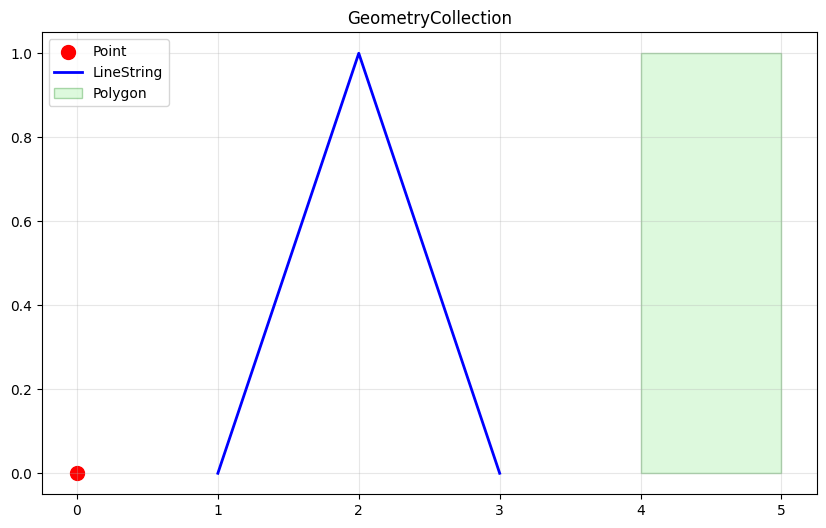

In [169]:
# Trực quan hóa các đa hình học
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for i, geom in enumerate(geom_collection.geoms):
    if geom.geom_type == 'Point':
        ax.scatter(geom.x, geom.y, c='red', s=100, label='Point')
    elif geom.geom_type == 'LineString':
        x, y = geom.xy
        ax.plot(x, y, 'b-', linewidth=2, label='LineString')
    elif geom.geom_type == 'Polygon':
        x, y = geom.exterior.xy
        ax.fill(x, y, alpha=0.3, fc='lightgreen', ec='green', label='Polygon')
ax.set_title('GeometryCollection')
ax.legend()
ax.grid(True, alpha=0.3)

## Tóm tắt

Bạn đã hoàn thành Bài học Shapely - thư viện nền tảng cho các phép toán hình học trong Python GIS.

### Các khái niệm chính đã nắm vững:
- ✅ **Geometric objects**: Point, LineString, Polygon và các đối tượng hình học cơ bản
- ✅ **Geometric properties**: area, length, bounds, centroid và các thuộc tính không gian
- ✅ **Spatial relationships**: contains(), intersects(), touches(), within() cho phân tích quan hệ
- ✅ **Geometric operations**: buffer(), intersection(), union(), difference() cho xử lý không gian
- ✅ **Transformations**: rotate(), scale(), translate() cho biến đổi hình học
- ✅ **Multi-geometries**: MultiPoint, MultiLineString, MultiPolygon cho dữ liệu phức tạp

### Kỹ năng bạn có thể áp dụng:
- Tạo và thao tác các đối tượng hình học cho bài toán GIS thực tế
- Thực hiện phân tích không gian như buffer zones, intersection analysis
- Kiểm tra mối quan hệ địa lý giữa các features trong datasets
- Tối ưu hóa performance cho việc xử lý big geospatial data
- Chuẩn bị nền tảng vững chắc cho GeoPandas, Fiona và các thư viện GIS nâng cao